In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [19]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,1-Jan-20,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [6]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')

In [20]:
df = df.dropna(subset=['date_added'])
df['country']= df['country'].fillna('mid-asia')

In [21]:
df = df.dropna(subset=['date_added'])
df['country']= df['country'].fillna('mid-asia')

In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country            0
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [8]:
df['year_added'] = df['date_added'].dt.year

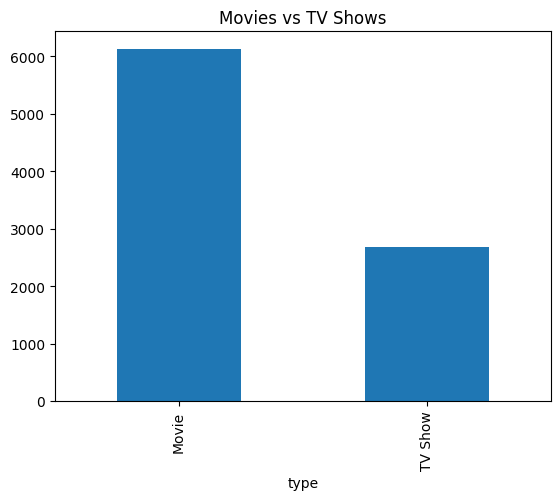

In [9]:
type_counts = df['type'].value_counts()

type_counts.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

In [24]:
df['release_year'].value_counts()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64

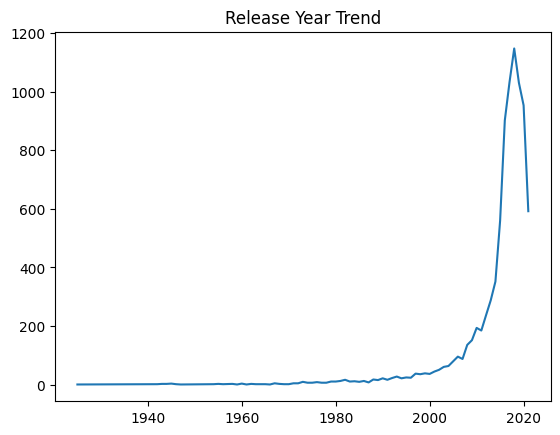

In [10]:
release_trend = df['release_year'].value_counts().sort_index()

plt.plot(release_trend.index, release_trend.values)
plt.title("Release Year Trend")
plt.show()

## Content Addition Trend Over Years

This analysis shows how the number of titles added to Netflix has changed over time.

- We can see that from the graph clearly that there is a sharp increase in content additions after 2000, and the graph has peaked near the 2020 yearline.
- This indicates rapid expansion and increased investment in content by Netflix in recent years

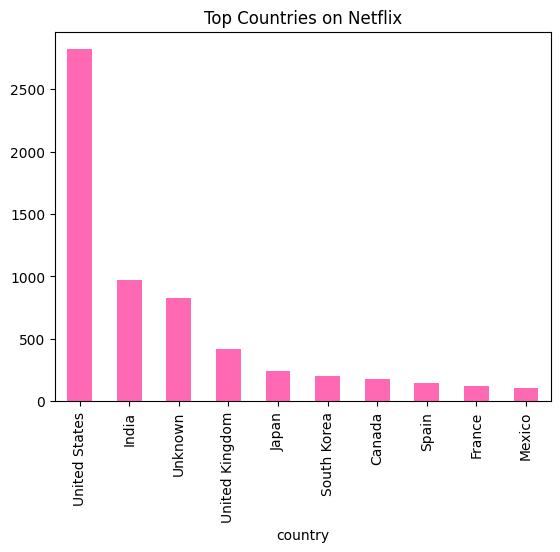

In [12]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar',color='hotpink')
plt.title("Top Countries on Netflix")
plt.show()

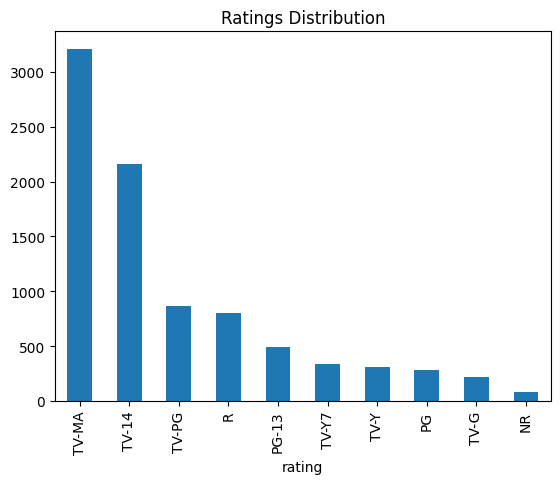

In [14]:
ratings = df['rating'].value_counts().head(10)

ratings.plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

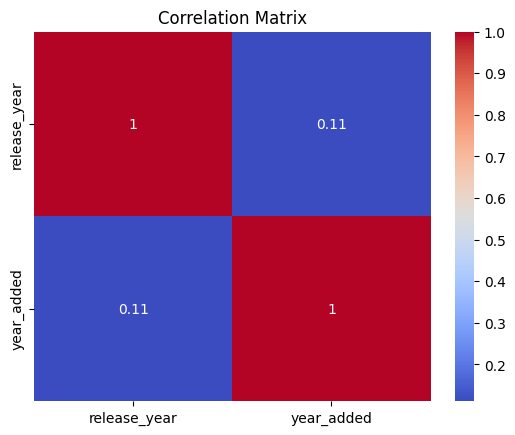

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

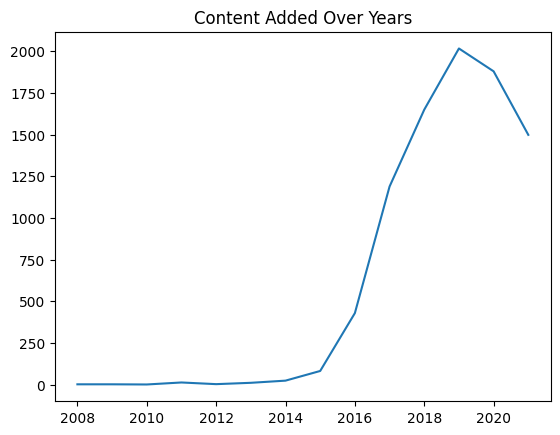

In [16]:
year_added_count = df['year_added'].value_counts().sort_index()

plt.plot(year_added_count.index, year_added_count.values)
plt.title("Content Added Over Years")
plt.show()

In [25]:
df.to_csv("netflix_cleaned.csv", index=False)

##  Final Conclusion:

- Netflix is movie-dominated platform
- Content increased rapidly after 2015
- USA is the biggest content contributor
- Most content is for mature audience (TV-MA)
- Netflix experienced peak growth in 2018–2020
